## Synthetic Control

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt

collisions_ca = pd.read_csv(r"California_Collisions_Clean.csv")

In [54]:
!pip install sdid

In [55]:
from sdid import SyntheticDiffInDiff

## Fix Data before Modeling

In [56]:
collisions_ca

,Unnamed: 0,case_id,collision_date,county_city_location,collision_severity,county_location,population,weather_1,primary_collision_factor,pcf_violation_category,...,alcohol_involved,latitude,longitude,CntyCode,County,Code,Agency,Start,End,year_month
0,5,4392009,2010-02-06,3616,fatal,san bernardino,100000 to 250000,raining,vehicle code violation,speeding,...,NaN,NaN,NaN,36.0,San Bernardino County,3616,Rancho Cucamonga,1/1/1984,NaN,2010-02
1,6,4392010,2010-01-24,1005,fatal,fresno,>250000,clear,vehicle code violation,pedestrian right of way,...,NaN,NaN,NaN,10.0,Fresno County,1005,Fresno,NaN,NaN,2010-01
2,7,4392011,2010-01-15,1005,fatal,fresno,>250000,fog,vehicle code violation,dui,...,1.0,NaN,NaN,10.0,Fresno County,1005,Fresno,NaN,NaN,2010-01
3,12,4392016,2010-01-14,1955,fatal,los angeles,100000 to 250000,clear,vehicle code violation,traffic signals and signs,...,NaN,NaN,NaN,19.0,Los Angeles County,1955,Pomona,NaN,NaN,2010-01
4,20,4392048,2010-02-13,3607,fatal,san bernardino,100000 to 250000,clear,vehicle code violation,speeding,...,NaN,NaN,NaN,36.0,San Bernardino County,3607,Ontario,NaN,NaN,2010-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613010,2929177,90018346,2015-09-10,3801,other injury,san francisco,>250000,clear,vehicle code violation,following too closely,...,NaN,37.72681,-122.40187,38.0,San Francisco County,3801,San Francisco,NaN,NaN,2015-09
613011,2929179,90218184,2016-05-07,1005,fatal,fresno,>250000,clear,other than driver,other than driver (or pedestrian),...,NaN,36.74674,-119.82226,10.0,Fresno County,1005,Fresno,NaN,NaN,2016-05
613012,2929184,90326285,2015-12-06,3009,fatal,orange,100000 to 250000,clear,vehicle code violation,dui,...,1.0,33.78883,-117.93185,30.0,Orange County,3009,Garden Grove,NaN,NaN,2015-12
613013,2929185,6606397,2015-09-19,1953,property damage only,los angeles,100000 to 250000,clear,other improper driving,other improper driving,...,NaN,NaN,NaN,19.0,Los Angeles County,1953,Pasadena,NaN,NaN,2015-09


In [57]:
#restructure data
monthly_did_data = (collisions_ca.groupby(['Agency', 'year_month'])
             .size()
             .reset_index(name='crashes'))

monthly_did_data['year_month'] = pd.to_datetime(monthly_did_data['year_month'])
monthly_did_data['year_month'] = monthly_did_data['year_month'].astype('period[M]')
monthly_did_data['year_month'] = monthly_did_data['year_month'].dt.to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

print(monthly_did_data.shape)
print(monthly_did_data.columns)

(2520, 3)
Index(['Agency', 'year_month', 'crashes'], dtype='object')


In [58]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'

monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)


###  Find Control Cities

In [59]:
for c in monthly_did_data['Agency'].unique():
  print(c)

Anaheim
Bakersfield
Berkeley
Corona
Downey
Fontana
Fresno
Fullerton
Garden Grove
Glendale
Hayward
Huntington Beach
Irvine
Long Beach
Modesto
Norwalk
Oakland
Ontario
Orange
Pasadena
Pomona
Rancho Cucamonga
Riverside
Sacramento
San Bernardino
San Francisco
Santa Ana
Santa Rosa
Stockton
Thousand Oaks


### Convert Year Month Variable to a numeric counter

In [60]:
#Convert time to readable format
# Convert year_month to numeric (months since first period)
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [61]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

'==================================================\nSynthetic Difference-in-Differences Results\n==================================================\nTreatment Effect (ATT): 194.6364\nControl units used:    7\nTime periods used:     0\n=================================================='

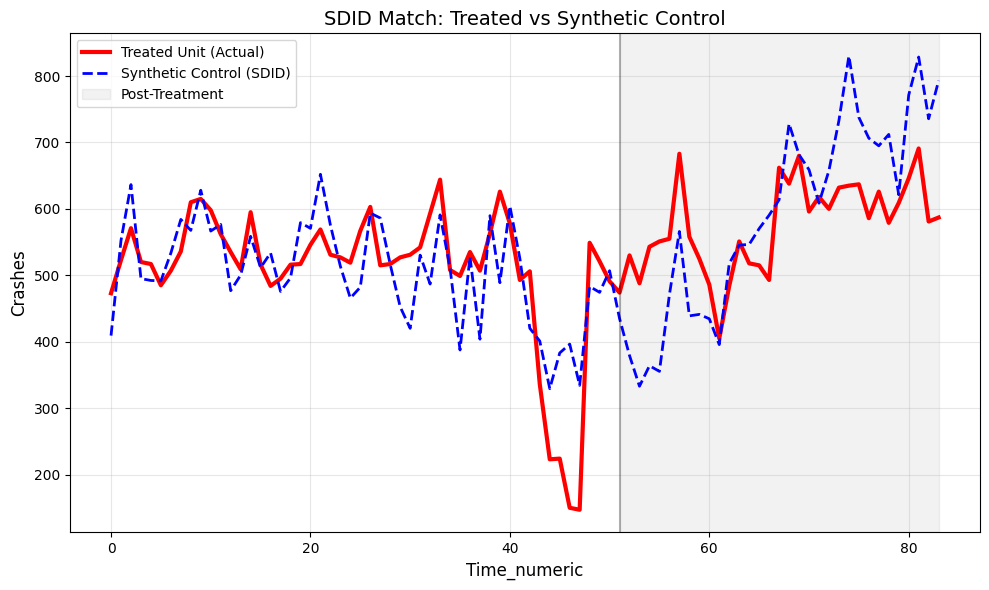

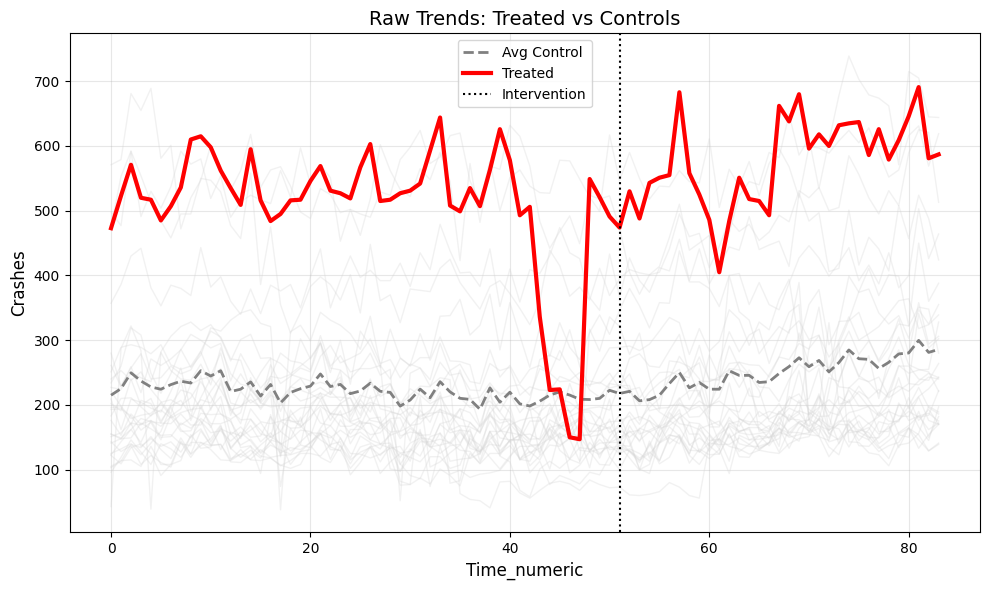

In [62]:
# 1. Synthetic control vs actual SF trends
model.plot_synthetic_control()

# 2. Raw trends for all cities
model.plot_raw_trends()

# Also print the full summary
model.summary()

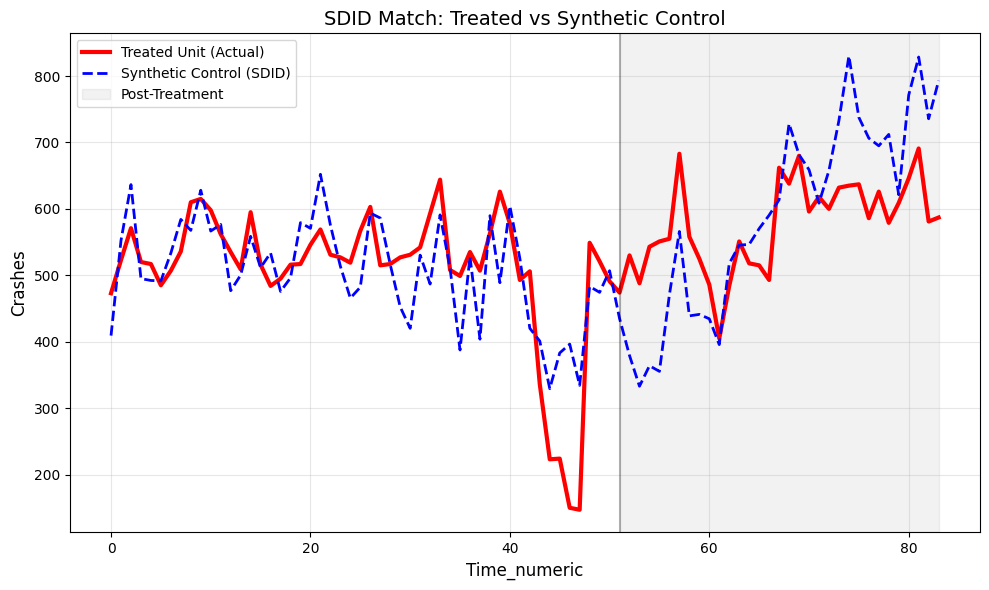

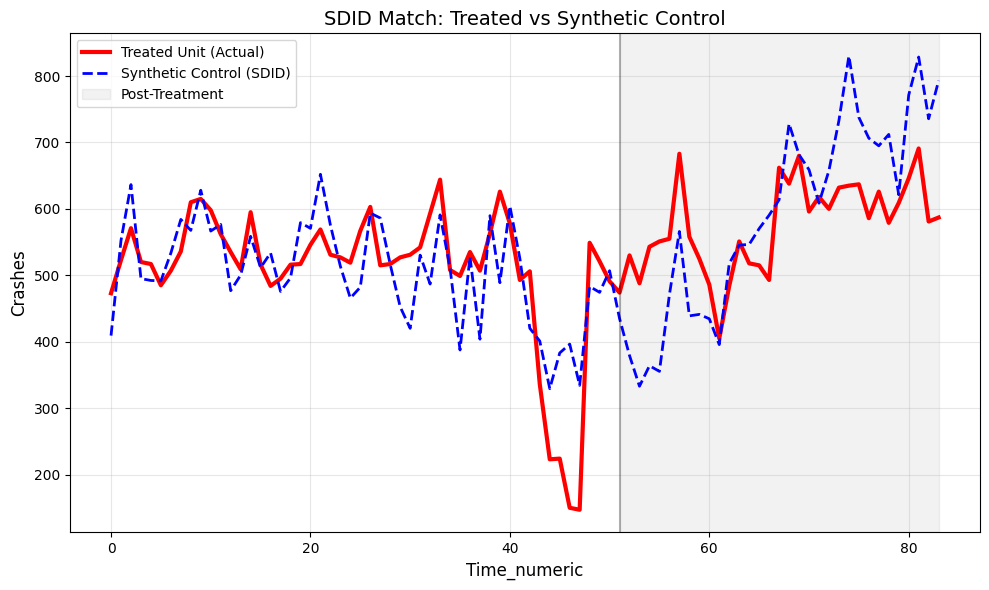

In [63]:
model.plot_synthetic_control()

<class 'matplotlib.figure.Figure'>


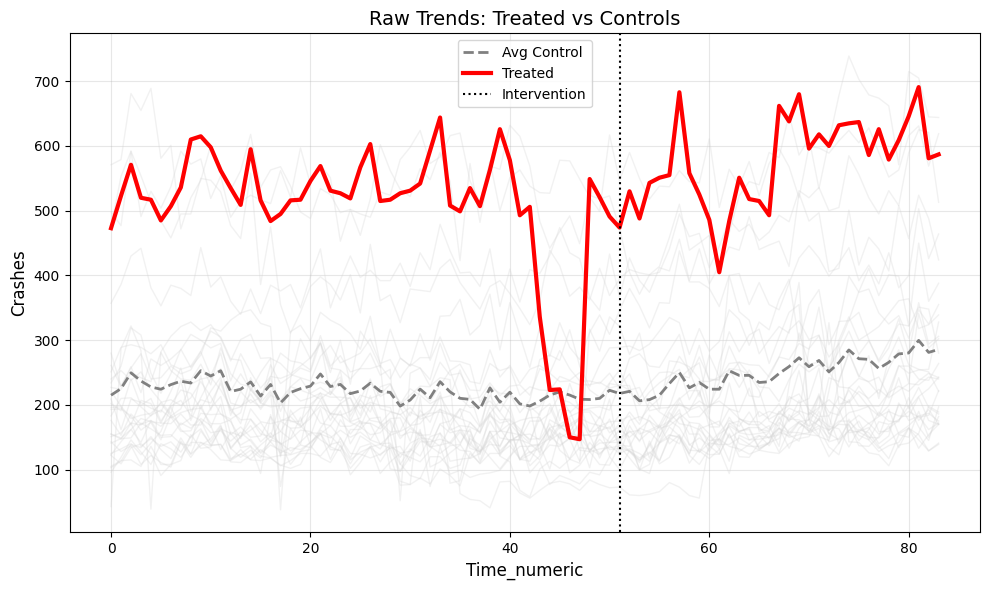

In [64]:
result = model.plot_raw_trends()
print(type(result))

In [65]:
for ax in result.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

plt.show()

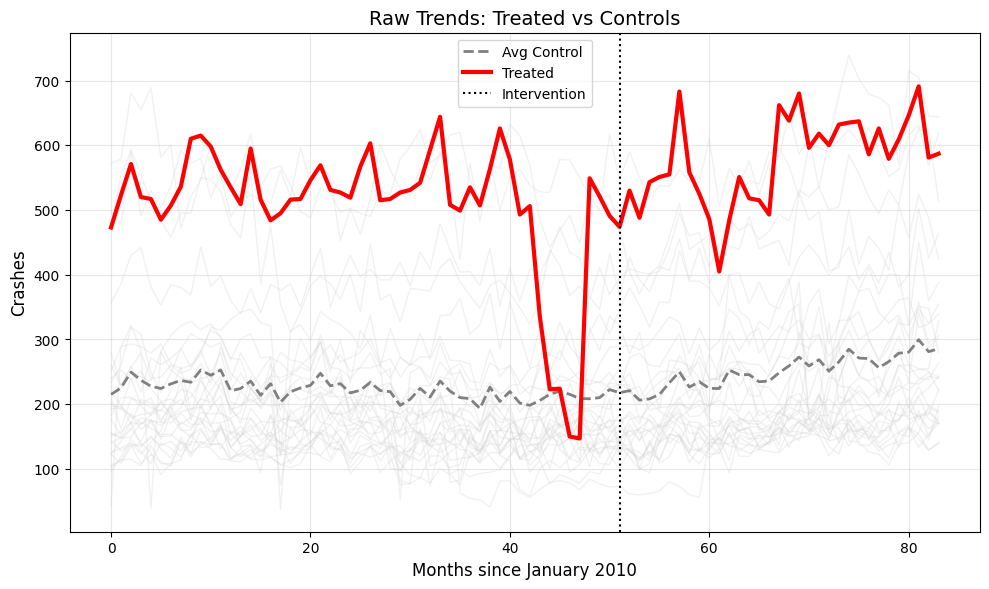

In [66]:
result

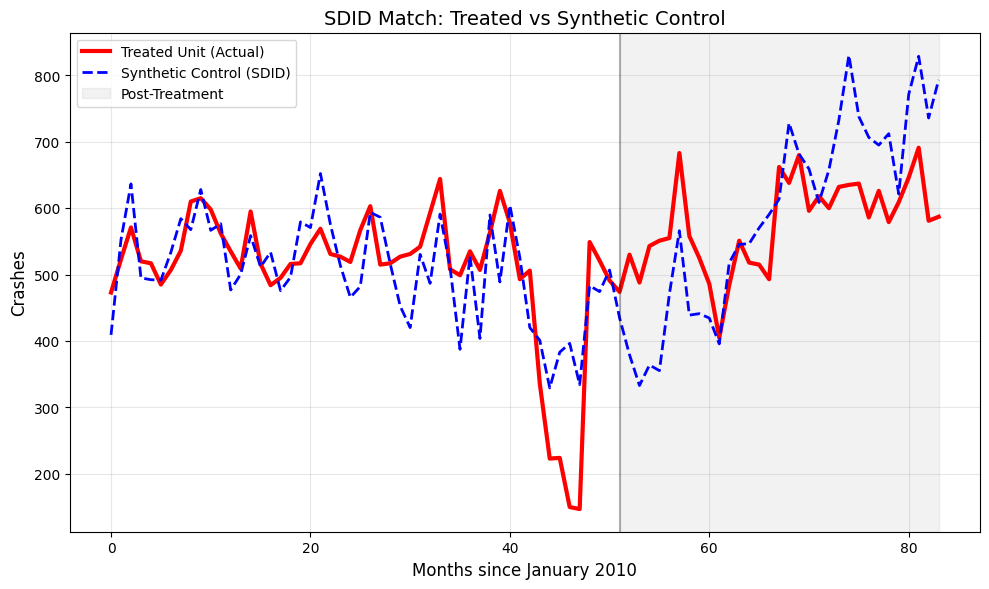

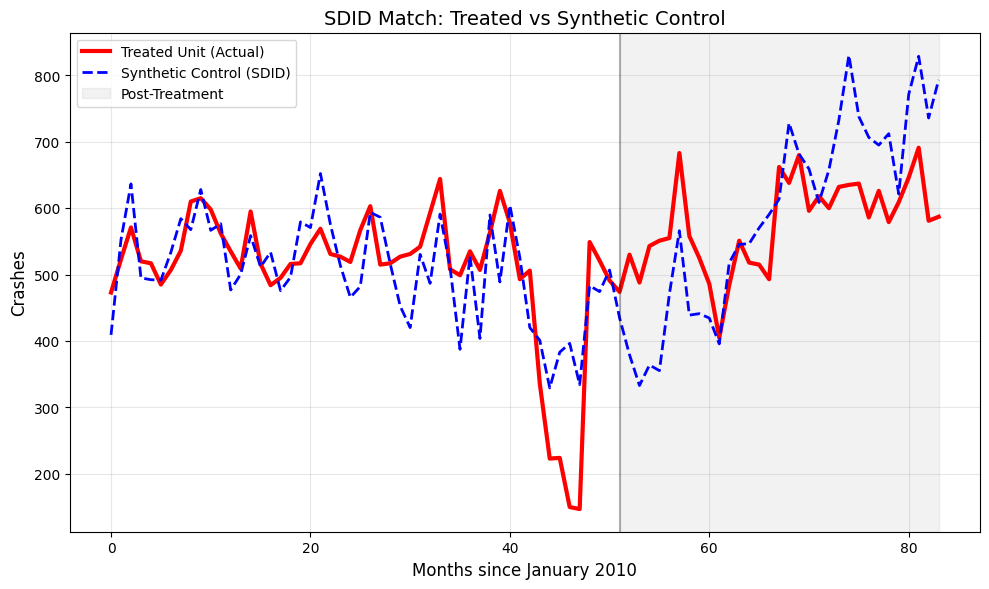

In [67]:
result2 = model.plot_synthetic_control()

for ax in result2.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

result2

In [68]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 194.6364
Standard Error:        82.5409
95% Confidence Interval: [32.8591, 356.4136]
t-statistic:           2.3581
p-value:               0.0184
Control units used:    7
Time periods used:     0


In [69]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.123325   1.0
 Pasadena      0.828449   2.0
 Garden Grove  0.531012   3.0
 Riverside     0.515513   4.0
 Fresno        0.281694   5.0
 Stockton      0.070187   6.0
 Corona        0.052414   7.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}

In [70]:
# Exact formula from library source code
control_wide = model.data[~model.data[model.post_col]].pivot(
    index=model.times_col,
    columns=model.units_col,
    values=model.outcome_col
)

# Valid controls with non-zero weights
valid_controls = model.unit_weights.index.intersection(control_wide.columns)

# Weighted average (unnormalized — library uses raw weights with .dot())
synthetic_trend = control_wide[valid_controls].dot(model.unit_weights[valid_controls])

# Treated outcome
treated_outcome = (
    model.data[model.data[model.treat_col]]
    .groupby(model.times_col)[model.outcome_col]
    .mean()
)

# Level adjustment — pre-treatment mean difference
pre_periods = model.data[~model.data[model.post_col]][model.times_col].unique()
common_pre = [p for p in pre_periods if p in treated_outcome.index and p in synthetic_trend.index]

treated_pre_mean   = treated_outcome.loc[common_pre].mean()
synthetic_pre_mean = synthetic_trend.loc[common_pre].mean()
diff_mean          = treated_pre_mean - synthetic_pre_mean

synthetic_control = synthetic_trend + diff_mean

# ASMD — now using the same SC the plot uses
mean_treated = treated_outcome.loc[common_pre].mean()
mean_sc      = synthetic_control.loc[common_pre].mean()
std_donors   = control_wide[valid_controls].std().mean()

asmd = abs(mean_treated - mean_sc) / std_donors

print(f"diff_mean (level adjustment): {diff_mean:.1f}")
print(f"Treated pre mean:  {mean_treated:.1f}")
print(f"SC pre mean:       {mean_sc:.1f}")
print(f"ASMD:              {asmd:.4f}")

diff_mean (level adjustment): -574.5
Treated pre mean:  507.3
SC pre mean:       507.3
ASMD:              0.0000


ASMD is 0 because library forces SC to match the treated mean exactly by adding diff_mean. Instead, lets measure ASMD on the trend.

In [71]:
# Correct ASMD for SDID — measure how well SC tracks SF period-by-period
# not just the mean, but the variance of differences over time

pre_treated = treated_outcome.loc[common_pre]
pre_sc      = synthetic_control.loc[common_pre]

# Difference at each pre-treatment time period
pre_diff = pre_treated - pre_sc

# ASMD based on time-series variation (not means)
std_treated = pre_treated.std()

asmd_trend = pre_diff.std() / std_treated

print(f"Pre-treatment differences (SF - SC):")
print(pre_diff.describe())
print(f"\nSTD of differences:  {pre_diff.std():.2f}")
print(f"STD of SF:           {std_treated:.2f}")
print(f"ASMD (trend):        {asmd_trend:.4f}")
print(f"Max abs difference:  {pre_diff.abs().max():.2f}")
print(f"Mean abs difference: {pre_diff.abs().mean():.2f}")

Pre-treatment differences (SF - SC):
count    5.100000e+01
mean    -7.802038e-14
std      7.493316e+01
min     -2.464408e+02
25%     -3.104027e+01
50%      6.804618e+00
75%      4.983971e+01
max      1.371302e+02
dtype: float64

STD of differences:  74.93
STD of SF:           106.83
ASMD (trend):        0.7014
Max abs difference:  246.44
Mean abs difference: 55.23


STD of SF:            
-  how much SF fluctuates month-to-month

STD of differences:   
- how much the SC misses SF each month

ASMD (trend):           
- SC captures % of SF's variation

Mean abs difference:   
- on average SC is off by ±55 crashes/month

Max abs difference:
- worst single month miss